# Regresión Simple con PyTorch

En este cuaderno reemplazamos el método manual de descenso por gradiente por una implementación moderna basada en:

- `nn.Sequential` para definir la red
- `Dataset` y `DataLoader` para manejar lotes
- entrenamiento con `forward` y `backward`
- checkpoints (guardar mejor modelo, recuperar y continuar entrenamiento)

Este enfoque sigue la lógica trabajada en los cuadernillos 01, 02, 03 y 04.

## 1) Importaciones, GPU dedicada y configuración

Importamos librerías de análisis y PyTorch, fijamos semilla para reproducibilidad y configuramos el dispositivo para usar GPU dedicada (`cuda`) cuando esté disponible.

También activamos optimizaciones de `cuDNN` para acelerar entrenamiento en tarjetas NVIDIA.

In [149]:
import os
import random
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Configuración para GPU dedicada (NVIDIA) cuando está disponible
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("Si tienes GPU dedicada, instala PyTorch con soporte CUDA (pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121)")

Dispositivo en uso: cuda
CUDA disponible: True
GPU detectada: NVIDIA GeForce RTX 4050 Laptop GPU


In [150]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA runtime en torch: {torch.version.cuda}")
print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")

print("\nComando recomendado (GPU NVIDIA):")
print("pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")
print("\nSi ya tienes CUDA activa, no necesitas reinstalar.")

PyTorch version: 2.11.0+cu128
CUDA runtime en torch: 12.8
cuDNN habilitado: True
cuDNN version: 91900

Comando recomendado (GPU NVIDIA):
pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Si ya tienes CUDA activa, no necesitas reinstalar.


## 1.1) Librerías y backend para GPU dedicada

Esta celda muestra el estado de CUDA/cuDNN y deja los comandos recomendados para instalar la versión GPU de PyTorch en caso de que el entorno actual sea CPU-only.

## 2) Carga y preparación de datos

Leemos el CSV, definimos la variable objetivo `cnt`, convertimos variables categóricas con `get_dummies` y separamos matrices de entrada/salida para regresión.

In [151]:
data_path = os.path.join("..", "Datos0..csv")

df = pd.read_csv(data_path, sep=";")
target_col = "cnt"

X_df = df.drop(columns=[target_col])
X_df = pd.get_dummies(X_df, drop_first=False)

y = df[target_col].astype(np.float32).values.reshape(-1, 1)
X = X_df.astype(np.float32).values

print(f"Archivo: {os.path.abspath(data_path)}")
print(f"Muestras (m): {X.shape[0]}")
print(f"Features (n): {X.shape[1]}")
print(f"Cumple m >= 10000: {X.shape[0] >= 10000}")
print(f"Cumple n >= 10: {X.shape[1] >= 10}")
print(df.head())

Archivo: e:\USFX\6to Semestre\Ia\Inteligencia Artificial\Laboratorios\Datos0..csv
Muestras (m): 17379
Features (n): 12
Cumple m >= 10000: True
Cumple n >= 10: True
   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  cnt  
0  0.2879  0.81        0.0   16  
1  0.2727  0.80        0.0   40  
2  0.2727  0.80        0.0   32  
3  0.2879  0.75        0.0   13  
4  0.2879  0.75        0.0    1  


## 3) Partición train/valid y normalización (X e y)

Separamos entrenamiento y validación.

Normalizamos:

- `X` (features), para facilitar el aprendizaje
- `y` (target), para que la pérdida MSE quede en una escala más pequeña (cercana a 0-1)

Esto mantiene el estilo simple de los cuadernillos y mejora la lectura de la `loss`.

In [152]:
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

train_size = int(0.8 * len(indices))
train_idx = indices[:train_size]
val_idx = indices[train_size:]

X_train_raw = X[train_idx]
X_val_raw = X[val_idx]
y_train_raw = y[train_idx]
y_val_raw = y[val_idx]

# Normalización de features
mu = X_train_raw.mean(axis=0, keepdims=True)
sigma = X_train_raw.std(axis=0, keepdims=True)
sigma[sigma == 0] = 1.0
X_train = (X_train_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma

# Normalización de target para que la loss esté en escala pequeña
y_mu = y_train_raw.mean(axis=0, keepdims=True)
y_sigma = y_train_raw.std(axis=0, keepdims=True)
y_sigma[y_sigma == 0] = 1.0
y_train = (y_train_raw - y_mu) / y_sigma
y_val = (y_val_raw - y_mu) / y_sigma

print(f"Train: {X_train.shape}, Valid: {X_val.shape}")
print(f"y media train (original): {float(y_mu.squeeze()):.4f}")
print(f"y std train (original):   {float(y_sigma.squeeze()):.4f}")

Train: (13903, 12), Valid: (3476, 12)
y media train (original): 189.1821
y std train (original):   180.5942


## 4) Dataset personalizado y DataLoader

Creamos una clase `Dataset` para regresión y luego usamos `DataLoader` para iterar por mini-batches, igual que en los cuadernillos de redes neuronales.

In [153]:
class RegresionDataset(Dataset):
    def __init__(self, X_np, y_np):
        self.X = torch.from_numpy(X_np).float()
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RegresionDataset(X_train, y_train)
val_dataset = RegresionDataset(X_val, y_val)

# En Windows/Jupyter, num_workers>0 puede fallar por multiprocessing.
# Usamos configuración estable para notebook y GPU.
num_workers = 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape}, Batch y: {yb.shape}")
print(f"num_workers={num_workers}, pin_memory={pin_memory}")

Batch X: torch.Size([512, 12]), Batch y: torch.Size([512, 1])
num_workers=0, pin_memory=True


## 5) Modelo con nn.Sequential (versión simple)

Definimos una red neuronal sencilla para regresión, siguiendo el estilo introductorio de los cuadernillos:

- capa lineal de entrada
- activación ReLU
- capa lineal de salida (1 valor)

Usamos `MSELoss` y optimizador `Adam`, manteniendo un flujo claro y fácil de entender.

In [154]:
n_features = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print(f"Learning rate inicial: {optimizer.param_groups[0]['lr']}")

Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
)
Learning rate inicial: 0.001


## 6) Funciones de entrenamiento y validación (versión simple)

Implementamos el ciclo clásico de entrenamiento en PyTorch:

- `forward`
- cálculo de `loss`
- `backward`
- `optimizer.step()`

La validación se calcula con `torch.no_grad()` para no acumular gradientes.

In [155]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    losses = []

    for Xb, yb in dataloader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        y_hat = model(Xb)  # forward
        loss = criterion(y_hat, yb)
        loss.backward()    # backward
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    losses = []
    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb = Xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            y_hat = model(Xb)
            loss = criterion(y_hat, yb)
            losses.append(loss.item())
    return float(np.mean(losses))

## 7) Entrenamiento con checkpoints (estilo simple 01-04)

Este bloque sigue el enfoque sencillo de los cuadernillos:

- entrenar por épocas
- guardar siempre el último estado (`last_model.pt`)
- guardar el mejor modelo según `val_loss` (`best_model.pt`)

En cada checkpoint guardamos lo esencial:

- `epoch`
- `model_state_dict`
- `optimizer_state_dict`
- `best_val_loss`

Al final se verifica que ambos archivos existen y se muestra su tamaño.

In [156]:
# Carpeta local de checkpoints (igual de simple que en los cuadernillos)
checkpoint_dir = "./checkpoints_regresion_simple"
os.makedirs(checkpoint_dir, exist_ok=True)

best_ckpt_path = os.path.join(checkpoint_dir, "best_model.pt")
last_ckpt_path = os.path.join(checkpoint_dir, "last_model.pt")

# Reiniciamos checkpoints para evitar incompatibilidades de arquitecturas anteriores
for ckpt in [best_ckpt_path, last_ckpt_path]:
    if os.path.exists(ckpt):
        os.remove(ckpt)

print(f"Directorio actual: {os.path.abspath('.')}")
print(f"Carpeta checkpoints: {os.path.abspath(checkpoint_dir)}")

epochs = 1480
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Guardar SIEMPRE el último estado
    last_payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
    }
    torch.save(last_payload, last_ckpt_path)

    # Guardar mejor estado
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
        }
        torch.save(best_payload, best_ckpt_path)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train_loss: {train_loss:.6f} | val_loss: {val_loss:.6f} | "
            f"best_val_loss: {best_val_loss:.6f}"
        )


Directorio actual: e:\USFX\6to Semestre\Ia\Inteligencia Artificial\Laboratorios\Lab5
Carpeta checkpoints: e:\USFX\6to Semestre\Ia\Inteligencia Artificial\Laboratorios\Lab5\checkpoints_regresion_simple
Epoch 001/1480 | train_loss: 0.996918 | val_loss: 0.841018 | best_val_loss: 0.841018
Epoch 010/1480 | train_loss: 0.493256 | val_loss: 0.494956 | best_val_loss: 0.494956
Epoch 020/1480 | train_loss: 0.418467 | val_loss: 0.427778 | best_val_loss: 0.427778
Epoch 030/1480 | train_loss: 0.387796 | val_loss: 0.397448 | best_val_loss: 0.397448
Epoch 040/1480 | train_loss: 0.355826 | val_loss: 0.373451 | best_val_loss: 0.373451
Epoch 050/1480 | train_loss: 0.334939 | val_loss: 0.354314 | best_val_loss: 0.354314
Epoch 060/1480 | train_loss: 0.315271 | val_loss: 0.333795 | best_val_loss: 0.333795
Epoch 070/1480 | train_loss: 0.294590 | val_loss: 0.315451 | best_val_loss: 0.315451
Epoch 080/1480 | train_loss: 0.278130 | val_loss: 0.296944 | best_val_loss: 0.296944
Epoch 090/1480 | train_loss: 0.256

## 8) Cargar checkpoint (simple)

Cargamos primero `best_model.pt`. Si no existe, usamos `last_model.pt`.

Esto restaura pesos del modelo, estado del optimizador y época para continuar entrenamiento.

In [157]:
# Cargar best_model.pt y si no existe usar last_model.pt
load_path = best_ckpt_path if os.path.exists(best_ckpt_path) else last_ckpt_path

if not os.path.exists(load_path):
    raise FileNotFoundError(
        f"No existe checkpoint para cargar. Esperado: {best_ckpt_path} o {last_ckpt_path}"
    )

checkpoint = torch.load(load_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]
best_val_loss_loaded = checkpoint.get("best_val_loss", float("inf"))

model.eval()
print(f"Época recuperada: {start_epoch}")
print(f"Mejor val_loss recuperado: {best_val_loss_loaded:.6f}")

Época recuperada: 1470
Mejor val_loss recuperado: 0.068988


## 9) Evaluación del modelo recuperado (escala real)

El modelo se entrena con `y` normalizada, pero aquí desnormalizamos las predicciones para reportar métricas en la escala original de `cnt` (`MSE`, `RMSE`, `R²`).

In [158]:
model.eval()
with torch.no_grad():
    X_val_t = torch.from_numpy(X_val).float().to(device)
    y_val_pred_t = model(X_val_t)

# Predicción en escala normalizada
y_val_pred_norm = y_val_pred_t.cpu().numpy().reshape(-1, 1)

# Desnormalización a escala real de cnt
y_val_pred = (y_val_pred_norm * y_sigma + y_mu).reshape(-1)
y_val_true = y_val_raw.reshape(-1)

mse = float(np.mean((y_val_pred - y_val_true) ** 2))
rmse = float(np.sqrt(mse))
r2 = float(1 - np.sum((y_val_true - y_val_pred) ** 2) / np.sum((y_val_true - y_val_true.mean()) ** 2))

print(f"MSE : {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2 : {r2:.6f}")

MSE : 2288.901367
RMSE: 47.842464
R^2 : 0.932757


## 10) Precisión y matriz de confusión (salida discretizada)

Como este problema es de regresión, para obtener métricas de clasificación discretizamos `cnt` en 3 niveles (bajo, medio, alto) usando cuantiles del conjunto de entrenamiento.

Con eso calculamos:

- `accuracy`
- `precision` por clase y ponderada
- matriz de confusión

Además, graficamos la precisión por clase y la matriz de confusión.

Accuracy (3 clases): 0.8685
Precision weighted:   0.8684
Precision clase Bajo: 0.9144
Precision clase Medio: 0.8051
Precision clase Alto: 0.8844


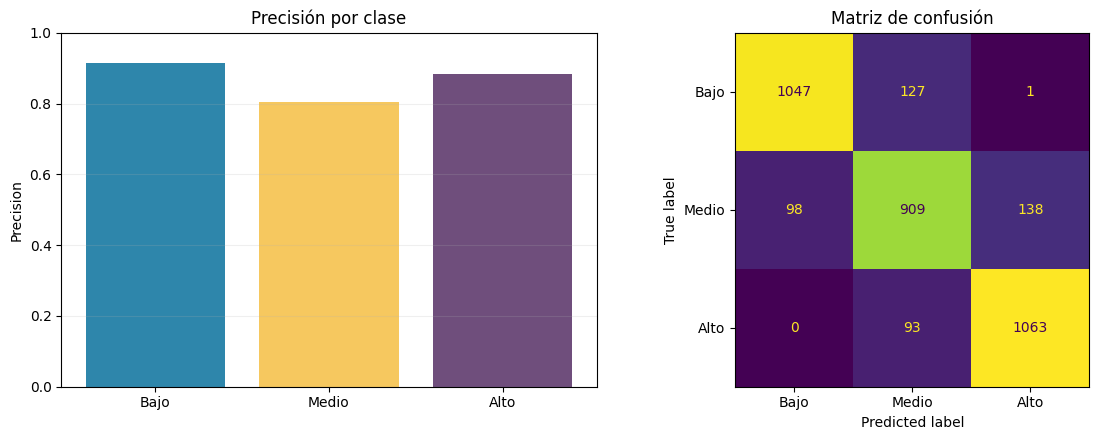

In [159]:
# Umbrales por cuantiles del target de entrenamiento en escala original (3 clases)
q1, q2 = np.quantile(y_train_raw.reshape(-1), [1/3, 2/3])
bins = [q1, q2]
class_names = ["Bajo", "Medio", "Alto"]

# Convertimos valores continuos a clases 0, 1, 2
y_true_cls = np.digitize(y_val_true, bins=bins, right=False)
y_pred_cls = np.digitize(y_val_pred, bins=bins, right=False)

acc = accuracy_score(y_true_cls, y_pred_cls)
prec_weighted = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
prec_per_class = precision_score(y_true_cls, y_pred_cls, average=None, labels=[0, 1, 2], zero_division=0)
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0, 1, 2])

print(f"Accuracy (3 clases): {acc:.4f}")
print(f"Precision weighted:   {prec_weighted:.4f}")
for i, p in enumerate(prec_per_class):
    print(f"Precision clase {class_names[i]}: {p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfica de precisión por clase
axes[0].bar(class_names, prec_per_class, color=["#2E86AB", "#F6C85F", "#6F4E7C"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Precisión por clase")
axes[0].set_ylabel("Precision")
axes[0].grid(axis="y", alpha=0.2)

# Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

## 10) Visualización de pérdidas y ajuste

Graficamos la evolución de `train_loss` y `val_loss`, además de un gráfico de `Predicción vs Real` para validar visualmente el ajuste.

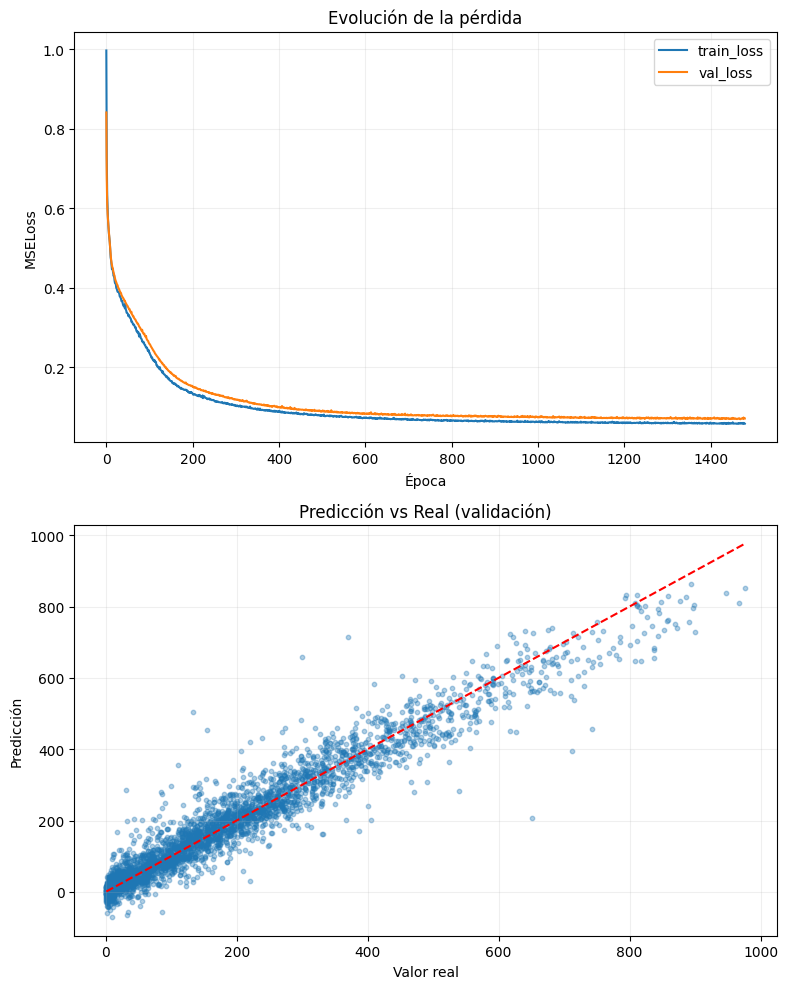

In [160]:
fig = plt.figure(figsize=(8, 10))

ax1 = fig.add_subplot(211)
ax1.plot(history["train_loss"], label="train_loss")
ax1.plot(history["val_loss"], label="val_loss")
ax1.set_title("Evolución de la pérdida")
ax1.set_xlabel("Época")
ax1.set_ylabel("MSELoss")
ax1.grid(alpha=0.2)
ax1.legend()

ax2 = fig.add_subplot(212)
ax2.scatter(y_val_true, y_val_pred, s=10, alpha=0.35)
min_v, max_v = float(y_val_true.min()), float(y_val_true.max())
ax2.plot([min_v, max_v], [min_v, max_v], "r--")
ax2.set_title("Predicción vs Real (validación)")
ax2.set_xlabel("Valor real")
ax2.set_ylabel("Predicción")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 11) Continuación de entrenamiento desde checkpoint

Demostramos la recuperación completa: retomamos el entrenamiento a partir del checkpoint guardado (modelo + optimizador + época).

In [161]:
extra_epochs = 10

for epoch in range(start_epoch + 1, start_epoch + extra_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    # Guardamos último estado en cada época de continuación
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss_loaded,
        },
        last_ckpt_path,
    )

    # Si mejora, actualizamos best_model.pt
    if val_loss < best_val_loss_loaded:
        best_val_loss_loaded = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss_loaded,
            },
            best_ckpt_path,
        )

    print(
        f"Resume Epoch {epoch:03d} | train_loss: {train_loss:.6f} | "
        f"val_loss: {val_loss:.6f} | best_val_loss: {best_val_loss_loaded:.6f}"
    )

Resume Epoch 1471 | train_loss: 0.057616 | val_loss: 0.069341 | best_val_loss: 0.068988
Resume Epoch 1472 | train_loss: 0.058047 | val_loss: 0.070973 | best_val_loss: 0.068988
Resume Epoch 1473 | train_loss: 0.058491 | val_loss: 0.072851 | best_val_loss: 0.068988
Resume Epoch 1474 | train_loss: 0.058729 | val_loss: 0.070011 | best_val_loss: 0.068988
Resume Epoch 1475 | train_loss: 0.058877 | val_loss: 0.070237 | best_val_loss: 0.068988
Resume Epoch 1476 | train_loss: 0.057453 | val_loss: 0.069883 | best_val_loss: 0.068988
Resume Epoch 1477 | train_loss: 0.057626 | val_loss: 0.070640 | best_val_loss: 0.068988
Resume Epoch 1478 | train_loss: 0.057457 | val_loss: 0.070224 | best_val_loss: 0.068988
Resume Epoch 1479 | train_loss: 0.057384 | val_loss: 0.070353 | best_val_loss: 0.068988
Resume Epoch 1480 | train_loss: 0.057744 | val_loss: 0.069856 | best_val_loss: 0.068988
